In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency
from sklearn. model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix, classification_report
import warnings
import joblib
warnings.filterwarnings('ignore')

In [75]:
#styling
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [76]:
#load the dataset
df = pd.read_csv(r'D:\Mlproject\Stroke Detection\healthcare-dataset-stroke-data.csv')
print(f"Dataset Shape: {df.shape}")
df.head(25)

Dataset Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [77]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [79]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [80]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [81]:
df.isnull().sum()/len(df)*100

id                   0.000000
gender               0.000000
age                  0.000000
hypertension         0.000000
heart_disease        0.000000
ever_married         0.000000
work_type            0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
bmi                  3.933464
smoking_status       0.000000
stroke               0.000000
dtype: float64

In [82]:
print("=== Data Information ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Handling missing values
# Fill missing BMI values with median
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# Check missing values
df.isnull().sum()

=== Data Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

=== Missing Values ===
id                     0
gender                 0
age                    0
hypertension           0
hea

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [83]:
def descriptive_stats(data):
    """Comprehensive descriptive statistics"""
    if isinstance(data, pd.Series):
        data = data.values
    stats_dict ={
        'count' : len(data),
        'mean' : np.mean(data),
        'median' : np.median(data),
        'std' : np.std(data, ddof=1),
        'min' : np.min(data),
        'max' : np.max(data),
        'q1' : np.percentile(data, 25),
        'q3' : np.percentile(data, 75),
        'iqr' : np.percentile(data, 75) - np.percentile(data, 25),
        'skewness' : stats.skew(data),
        'kurtosis' : stats.kurtosis(data)
    }
    return pd.Series(stats_dict)

In [84]:
# Example usage
print("Descriptive Statistic for hypertension:")
print(descriptive_stats(df['hypertension']))

Descriptive Statistic for hypertension:
count       5110.000000
mean           0.097456
median         0.000000
std            0.296607
min            0.000000
max            1.000000
q1             0.000000
q3             0.000000
iqr            0.000000
skewness       2.714595
kurtosis       5.369023
dtype: float64


In [85]:
# Quick pandas summary 
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.862035,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.699562,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


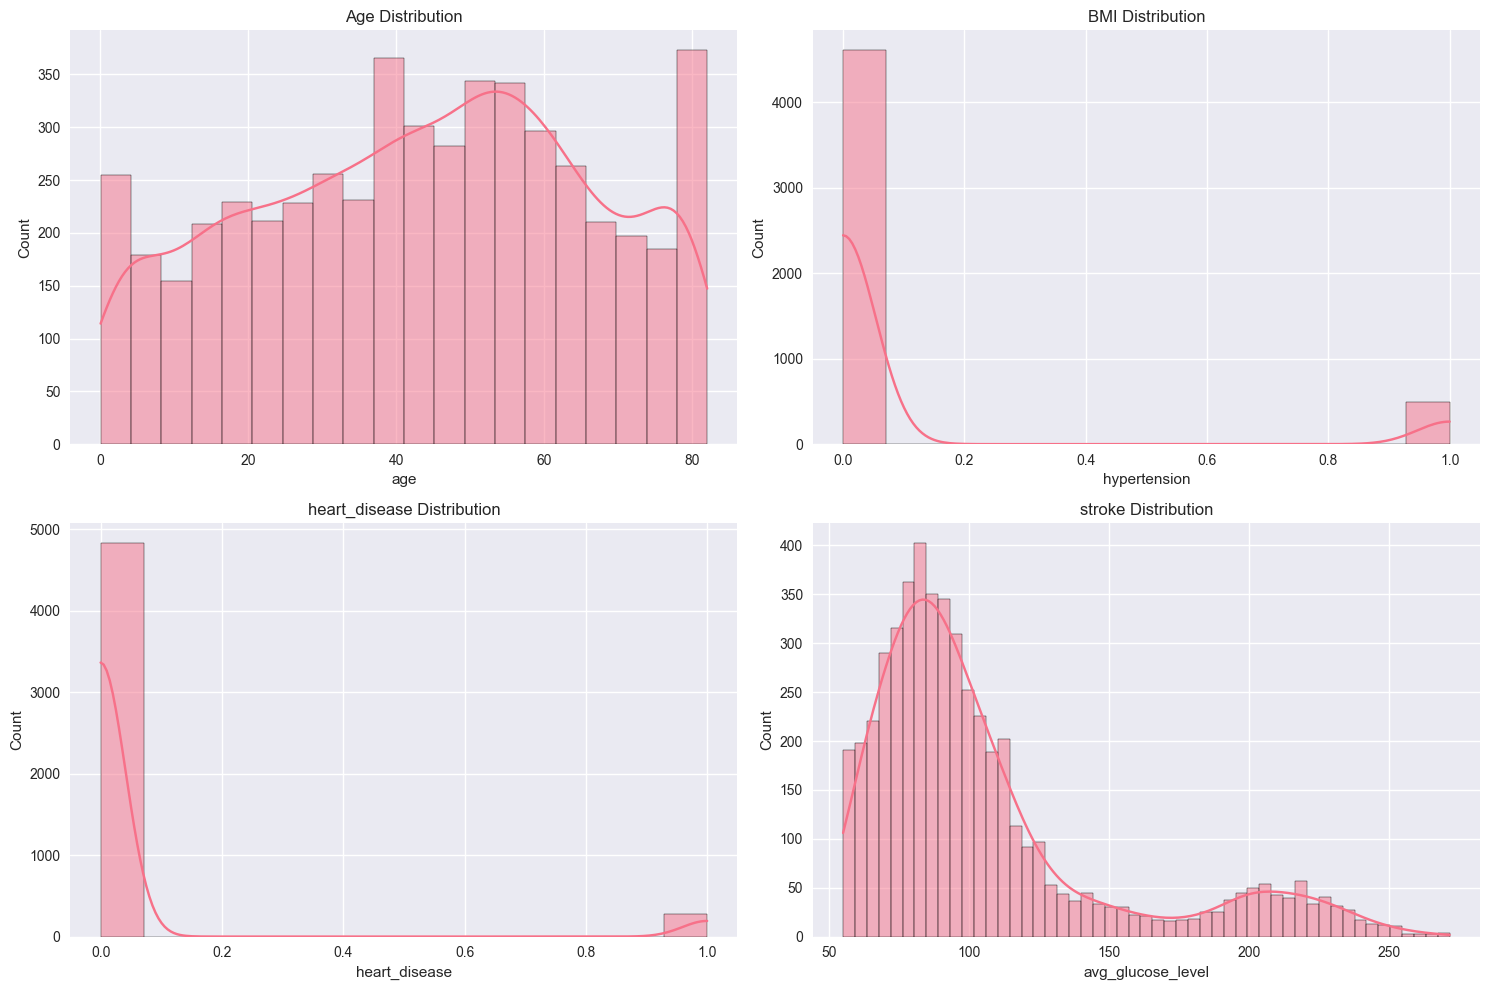

In [86]:
# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.histplot(df['age'], kde=True, ax=axes[0, 0]).set_title('Age Distribution')
sns.histplot(df['hypertension'], kde=True, ax=axes[0, 1]).set_title('BMI Distribution')
sns.histplot(df['heart_disease'], kde=True, ax=axes[1, 0]).set_title('heart_disease Distribution')
sns.histplot(df['avg_glucose_level'], kde=True, ax=axes[1, 1]).set_title('stroke Distribution')
plt.tight_layout()
plt.show()

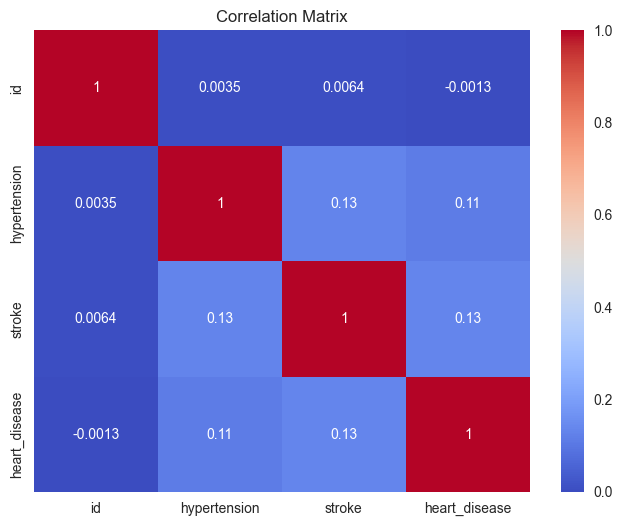

In [87]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
numeric_df = df[['id','hypertension','stroke','heart_disease']]
sns.heatmap(numeric_df.corr(),annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [88]:
print("=== 1. T-Test: Age by Gender ===")
male_age = df[df['gender'] == 'Male']['age']
female_age = df[df['gender'] == 'Female']['age']
t_stat, p_val = ttest_ind(male_age, female_age)
print(f"T-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")

print("\n=== 2.ANOVA: Glucose leve by Stroke Status===")
groups =[group['avg_glucose_level'].values for name, group in df.groupby('stroke')]
f_stat, p_val =f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}, P-value: {p_val:.4f}")

print("\n=== 3. Chi-Square Test ===")
contingency = pd.crosstab(df['gender'],df['stroke'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square: {chi2:.4f}, P-value: {p:4f}")

=== 1. T-Test: Age by Gender ===
T-statistic: -1.9840, p-value: 0.0473

=== 2.ANOVA: Glucose leve by Stroke Status===
F-statistic: 90.5039, P-value: 0.0000

=== 3. Chi-Square Test ===
Chi-square: 0.4726, P-value: 0.789549


In [89]:
#Regression :Predict Glucose level
x = pd.get_dummies(df.drop(['id','avg_glucose_level','gender'],axis=1),drop_first=True)
y = df['avg_glucose_level']

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(x_train,y_train)
y_pred = reg_model.predict(x_test)

print("=== regression Results ===")
print(f"R2 Score : {r2_score(y_test,y_pred):.4f}")
print(f"RMSE :{ np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

#save Model

joblib.dump(reg_model,'Stroke_regression_model.pkl')
print("✅ Model saved as 'Stroke_regression_model.pkl")

=== regression Results ===
R2 Score : 0.0779
RMSE :42.11
✅ Model saved as 'Stroke_regression_model.pkl


In [90]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

# -----------------------------
# Stroke Prediction Model
# -----------------------------

categorical_cols = [
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]

X = df.drop(['id', 'stroke'], axis=1)
y = df['stroke']

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(x_train, y_train)

pred = model.predict(x_test)

print("Accuracy :", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# Save model
joblib.dump(model, "stroke_prediction_model.pkl")

# Save feature names
joblib.dump(X.columns.tolist(), "model_columns.pkl")

print("Model Saved Successfully")

Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       960
           1       1.00      1.00      1.00        62

    accuracy                           1.00      1022
   macro avg       1.00      1.00      1.00      1022
weighted avg       1.00      1.00      1.00      1022

Model Saved Successfully


In [91]:
y.head(10)

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: stroke, dtype: int64